# Filtering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import scipy.signal as sig
import skimage.io as io
import skimage.data as data
import skimage.transform as transform
import skimage.color as color
import skimage.filters as filters

import matplotlib as mpl
plt.style.use('../../src/bip.mplstyle')
mpl.rcParams['xtick.bottom'] = False
mpl.rcParams['ytick.left'] = False
plt.rcParams['image.cmap'] = 'gray'

## Exemple pour le code Moodle

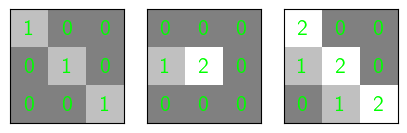

\( f = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \\ \end{pmatrix} \)
\( h = \begin{pmatrix} 0 & 0 & 0 \\ 1 & 2 & 0 \\ 0 & 0 & 0 \\ \end{pmatrix} \)
\( g = \begin{pmatrix} 2 & 0 & 0 \\ 1 & 2 & 0 \\ 0 & 1 & 2 \\ \end{pmatrix} \)



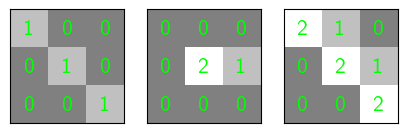

\( f = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \\ \end{pmatrix} \)
\( h = \begin{pmatrix} 0 & 0 & 0 \\ 0 & 2 & 1 \\ 0 & 0 & 0 \\ \end{pmatrix} \)
\( g = \begin{pmatrix} 2 & 1 & 0 \\ 0 & 2 & 1 \\ 0 & 0 & 2 \\ \end{pmatrix} \)



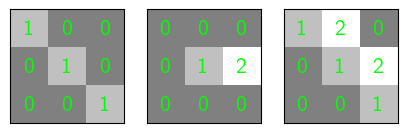

\( f = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \\ \end{pmatrix} \)
\( h = \begin{pmatrix} 0 & 0 & 0 \\ 0 & 1 & 2 \\ 0 & 0 & 0 \\ \end{pmatrix} \)
\( g = \begin{pmatrix} 1 & 2 & 0 \\ 0 & 1 & 2 \\ 0 & 0 & 1 \\ \end{pmatrix} \)



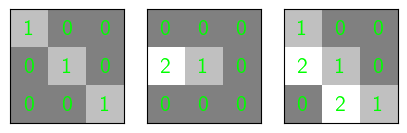

\( f = \begin{pmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \\ \end{pmatrix} \)
\( h = \begin{pmatrix} 0 & 0 & 0 \\ 2 & 1 & 0 \\ 0 & 0 & 0 \\ \end{pmatrix} \)
\( g = \begin{pmatrix} 1 & 0 & 0 \\ 2 & 1 & 0 \\ 0 & 2 & 1 \\ \end{pmatrix} \)



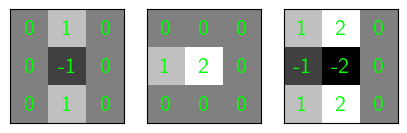

\( f = \begin{pmatrix} 0 & 1 & 0 \\ 0 & -1 & 0 \\ 0 & 1 & 0 \\ \end{pmatrix} \)
\( h = \begin{pmatrix} 0 & 0 & 0 \\ 1 & 2 & 0 \\ 0 & 0 & 0 \\ \end{pmatrix} \)
\( g = \begin{pmatrix} 1 & 2 & 0 \\ -1 & -2 & 0 \\ 1 & 2 & 0 \\ \end{pmatrix} \)



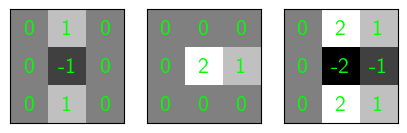

\( f = \begin{pmatrix} 0 & 1 & 0 \\ 0 & -1 & 0 \\ 0 & 1 & 0 \\ \end{pmatrix} \)
\( h = \begin{pmatrix} 0 & 0 & 0 \\ 0 & 2 & 1 \\ 0 & 0 & 0 \\ \end{pmatrix} \)
\( g = \begin{pmatrix} 0 & 2 & 1 \\ 0 & -2 & -1 \\ 0 & 2 & 1 \\ \end{pmatrix} \)



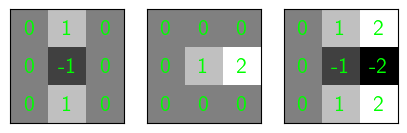

\( f = \begin{pmatrix} 0 & 1 & 0 \\ 0 & -1 & 0 \\ 0 & 1 & 0 \\ \end{pmatrix} \)
\( h = \begin{pmatrix} 0 & 0 & 0 \\ 0 & 1 & 2 \\ 0 & 0 & 0 \\ \end{pmatrix} \)
\( g = \begin{pmatrix} 0 & 1 & 2 \\ 0 & -1 & -2 \\ 0 & 1 & 2 \\ \end{pmatrix} \)



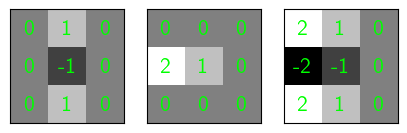

\( f = \begin{pmatrix} 0 & 1 & 0 \\ 0 & -1 & 0 \\ 0 & 1 & 0 \\ \end{pmatrix} \)
\( h = \begin{pmatrix} 0 & 0 & 0 \\ 2 & 1 & 0 \\ 0 & 0 & 0 \\ \end{pmatrix} \)
\( g = \begin{pmatrix} 2 & 1 & 0 \\ -2 & -1 & 0 \\ 2 & 1 & 0 \\ \end{pmatrix} \)



In [10]:
# Exemples pour le quiz Moodle

def moodle_code(img, var, num):
    """Code à insérer dans le quiz Moodle
    img : image (array)
    var : variable associée à l'image (f, g ou h)
    num : numéro d'identification (string)
    """

    # Valeurs de la matrice
    matrix = ""
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            matrix += f" {img[i][j]} &"
        matrix = matrix[:-2] + r" \\"
    code = rf"\( {var} = \begin{{pmatrix}}{matrix} \end{{pmatrix}} \)"
    print(code)
                
def moodle_image(ax, img):
    """Affichage de l'image, pour que je vois ce que ça donne"""

    # Affichage de l'image
    ax.imshow(img, vmin=-2, vmax=2)

    # Axes
    ax.set_xticks([])
    ax.set_yticks([])

    # Intensités
    for x in range(img.shape[0]):
        for y in range(img.shape[1]):
            ax.text(y,x, f"{img[x,y]:.0f}", color='#0f0', ha='center', va='center')


fs = [
    [ [1, 0, 0], [0, 1, 0], [0, 0, 1] ],
    [ [0, 1, 0], [0, -1, 0], [0, 1, 0] ],
]
hs = [
    [ [0, 0, 0], [1, 2, 0], [0, 0, 0] ],
    [ [0, 0, 0], [0, 2, 1], [0, 0, 0] ],
    [ [0, 0, 0], [0, 1, 2], [0, 0, 0] ],
    [ [0, 0, 0], [2, 1, 0], [0, 0, 0] ],
]

for m in range(len(fs)):
    for n in range(len(hs)):

        # Calcul de la convolution
        f = np.array(fs[m])
        h = np.array(hs[n])
        g = sig.convolve2d(f, h, mode='same')

        # Affichage
        fig, axs = plt.subplots(1, 3, figsize=(5,10))
        moodle_image(axs[0], f)
        moodle_image(axs[1], h)
        moodle_image(axs[2], g)
        plt.show()

        # Code Moodle
        moodle_code(f, "f", m)
        moodle_code(h, "h", n)
        moodle_code(g, "g", n)
        print()

## Examples of image convolution

In [3]:
def image(ax, img, lbl, vmax, intensities=False, center=False):

    # Affichage de l'image
    ax.imshow(img, vmin=0, vmax=vmax)

    # Axes
    ax.set_xlabel(lbl, labelpad=-10)
    if center:
        # Le 0 est au centre de l'image
        ax.set_xticks([0, img.shape[1]-1], [-(img.shape[1]-1)//2, (img.shape[1]-1)//2])
        ax.set_yticks([0, img.shape[0]-1], [-(img.shape[0]-1)//2, (img.shape[0]-1)//2])
    else:
        # Le 0 est en haut à gauche de l'image
        ax.set_xticks([0, img.shape[1]-1])
        ax.set_yticks([0, img.shape[0]-1])

    # Affiche une grille et les valeurs des pixels
    if intensities:
        
        # Grille
        for x in range(img.shape[0]-1):
            ax.axvline(x+.5, color='gray', linewidth=1)
        for y in range(img.shape[1]-1):
            ax.axhline(y+.5, color='gray', linewidth=1)

        # Intensités
        for x in range(img.shape[0]):
            for y in range(img.shape[1]):
                ax.text(y,x, f"{img[x,y]:.0f}", color='#0f0', ha='center', va='center')

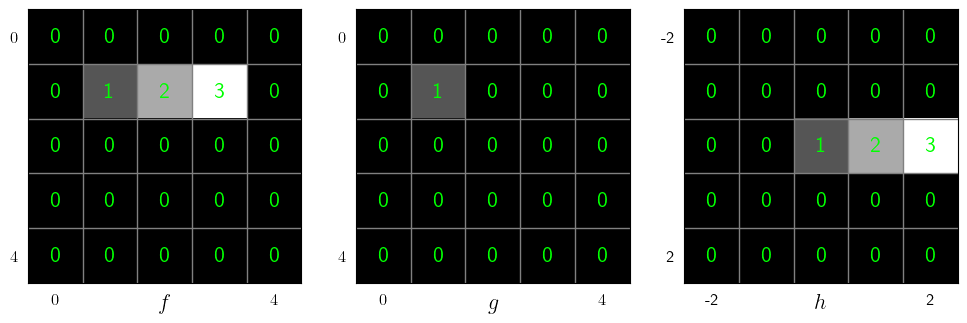

In [8]:
# Convolution of a small image, with pixel intensities

g = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])
h = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 2, 3],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])
f = sig.convolve2d(g, h, mode='same')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
image(axs[0], f, "$f$", vmax=f.max(), intensities=True)
image(axs[1], g, "$g$", vmax=f.max(), intensities=True)
image(axs[2], h, "$h$", vmax=f.max(), intensities=True, center=True)
plt.savefig("conv-example1.svg")

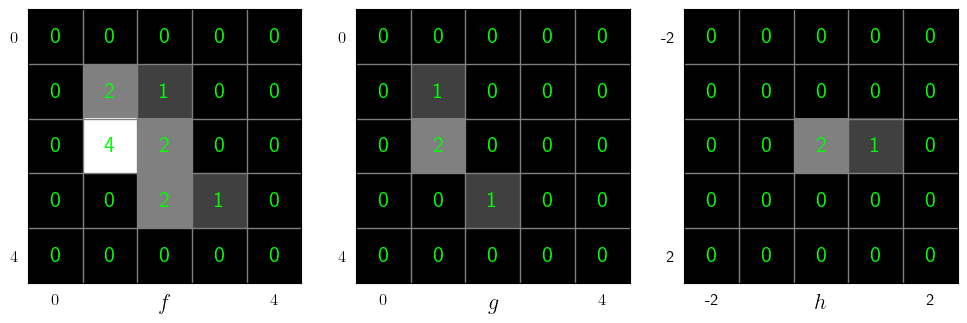

In [6]:
# Convolution of a small image, with pixel intensities

g = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 2, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
])
h = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 2, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])
f = sig.convolve2d(g, h, mode='same')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
image(axs[0], f, "$f$", vmax=f.max(), intensities=True)
image(axs[1], g, "$g$", vmax=f.max(), intensities=True)
image(axs[2], h, "$h$", vmax=f.max(), intensities=True, center=True)
plt.savefig("conv-example2.svg")

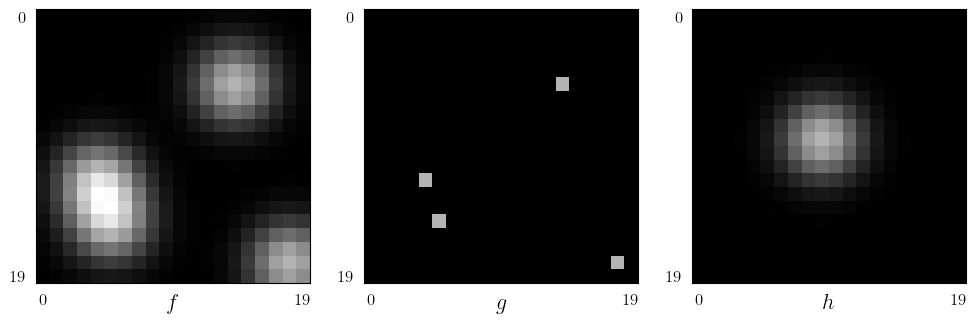

In [38]:
# Convolution of some Diracs

g = np.zeros((20,20))
g[15, 5] = 1
g[12, 4] = 1
g[5, 14] = 1
g[18, 18] = 1
d = np.zeros((20, 20))
d[9, 9] = 1
h = ndi.gaussian_filter(d, sigma=2)
h = h / h.max()
f = sig.convolve2d(g, h, mode='same')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
image(axs[0], f, "$f$", vmax=f.max())
image(axs[1], g, "$g$", vmax=f.max())
image(axs[2], h, "$h$", vmax=f.max())
plt.savefig("conv-example3.svg")

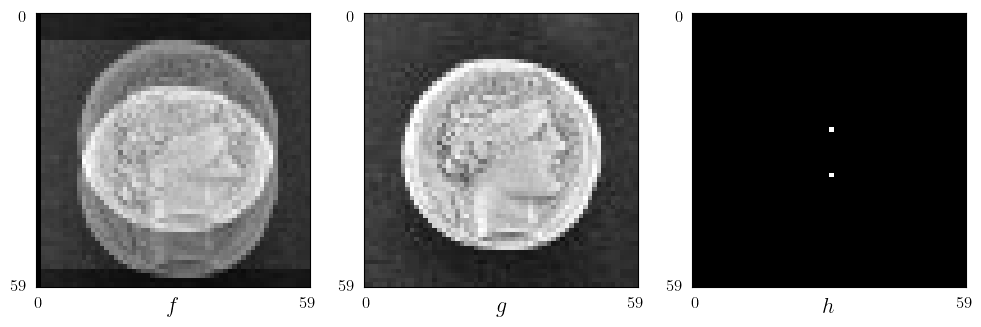

In [39]:
# Convolution by 2 Diracs

g = data.coins()
g = g[165:225, 72:132]
sigma = 7
h = np.zeros((60,60))
h[25, 30] = 1
h[35, 30] = 1
h = h/np.sum(np.sum(h))
f = sig.convolve2d(g, h, mode='same')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
image(axs[0], f, "$f$", vmax=f.max())
image(axs[1], g, "$g$", vmax=f.max())
image(axs[2], h, "$h$", vmax=h.max())
plt.savefig("conv-example4.svg")

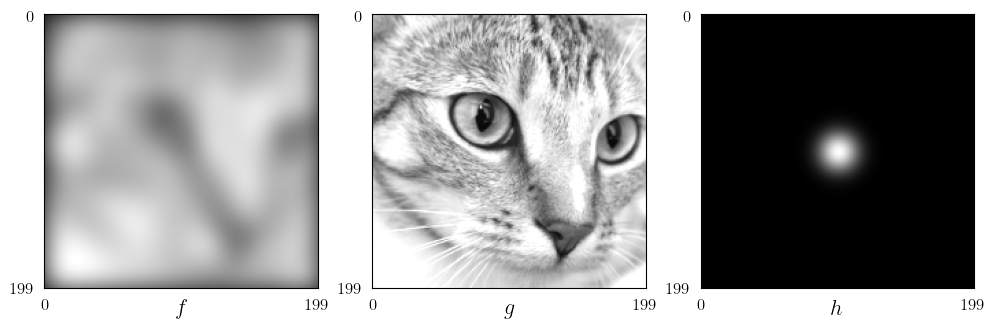

In [40]:
# Blurring effect

g = color.rgb2gray( data.cat() )
g = g[:,50:350]
g = transform.resize(g, (200, 200))
d = np.zeros((200,200))
d[100, 100] = 1
h = ndi.gaussian_filter(d, sigma=10)
h = h/np.sum(np.sum(h))
f = sig.convolve2d(g, h, mode='same')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
image(axs[0], f, "$f$", vmax=f.max())
image(axs[1], g, "$g$", vmax=f.max())
image(axs[2], h, "$h$", vmax=h.max())
plt.savefig("conv-example5.svg")

## Boundaries effects

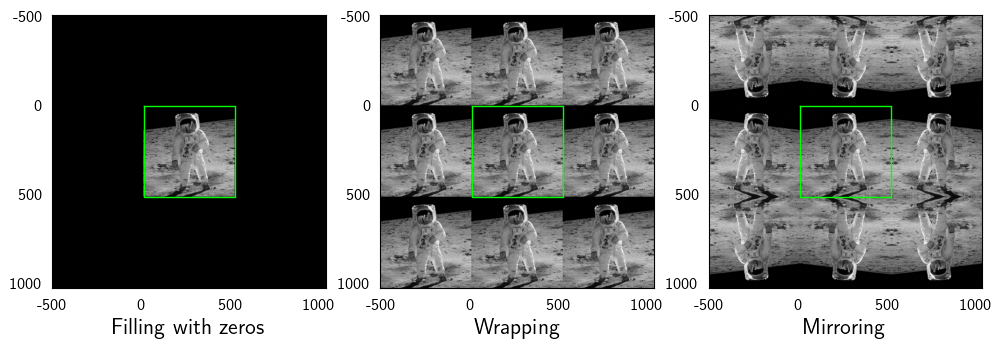

In [41]:
# Image to convolve
img = io.imread("../../src/figs/aldrin.png")
img = color.rgb2gray(img)
N = img.shape[0]

# Fill with 0
img_zeros = np.zeros((3*N, 3*N))
img_zeros[N:2*N, N:2*N] = img

# Wrap (periodic or circular condition)
img_wrap = np.zeros((3*N, 3*N))
for x in range(3):
    for y in range(3):
        img_wrap[x*N:(x+1)*N, y*N:(y+1)*N] = img

# Mirror (symmetrical condition)
img_symm = np.zeros((3*N, 3*N))
for x in range(3):
    for y in range(3):
        xdir = -1 if (x%2) == 0 else 1
        ydir = -1 if (y%2) == 0 else 1
        img_symm[x*N:(x+1)*N, y*N:(y+1)*N] = img[::xdir,::ydir]

def image(ax, img, label):
    N = 500
    ax.imshow(img, cmap="gray")
    ax.set_xlabel(label)
    ax.set_xticks(np.arange(0, 3*N+1, N))
    ax.set_xticklabels(np.arange(-N, 2*N+1, N))
    ax.set_yticks(np.arange(0, 3*N+1, N))
    ax.set_yticklabels(np.arange(-N, 2*N+1, N))
    
# Display
fig, axs = plt.subplots(1,3, figsize=(12,4))
image(axs[0], img_zeros, "Filling with zeros")
axs[0].plot([N,2*N,2*N,N,N],[N,N,2*N,2*N,N],'#0f0', linewidth=1)
image(axs[1], img_wrap, "Wrapping")
axs[1].plot([N,2*N,2*N,N,N],[N,N,2*N,2*N,N],'#0f0', linewidth=1)
image(axs[2], img_symm, "Mirroring")
axs[2].plot([N,2*N,2*N,N,N],[N,N,2*N,2*N,N],'#0f0', linewidth=1)

plt.savefig("boundaries-hypotheses.svg")

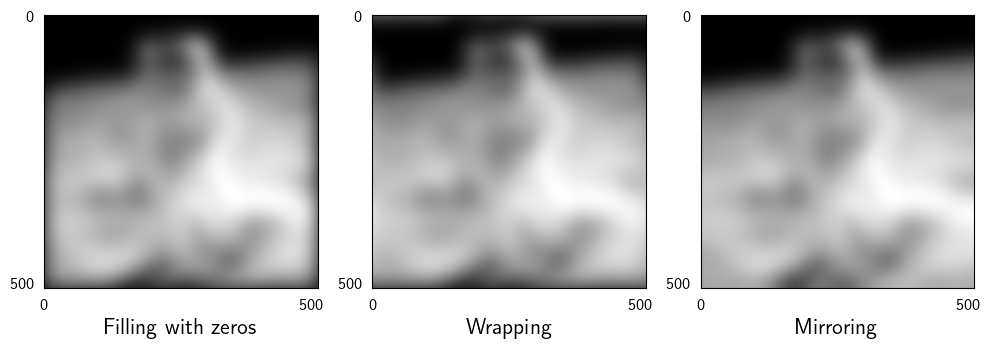

In [42]:
# Convolution of the previous images by a Gaussian PSF
sigma = 20
img_zeros = filters.gaussian(img, sigma=sigma, mode='constant', cval=0)
img_wrap = filters.gaussian(img, sigma=sigma, mode='wrap')
img_symm = filters.gaussian(img, sigma=sigma, mode='mirror')

def image(ax, img, label):
    N = 500
    ax.imshow(img, cmap="gray")
    ax.set_xlabel(label)
    ax.set_xticks(np.arange(0, N+1, N))
    ax.set_xticklabels(np.arange(0, N+1, N))
    ax.set_yticks(np.arange(0, N+1, N))
    ax.set_yticklabels(np.arange(0, N+1, N))

# Display
fig, axs = plt.subplots(1,3, figsize=(12,4))
image(axs[0], img_zeros, "Filling with zeros")
image(axs[1], img_wrap, "Wrapping")
image(axs[2], img_symm, "Mirroring")

plt.savefig("boundaries-results.svg")